# Logistic Regression Model

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Data Preparation ###
expeditions = "data/expeditions.csv"

# Load the CSV file
df = pd.read_csv(expeditions)

# Filter Data: Consider expeditions where the maximum elevation reached is above 7000 meters 
# (likely to focus on higher-risk expeditions)
df = df[df['max_elev_reached'] > 7000]

# List of some of the features from the dataset to be measured
features = ['peak_name', 'year', 'season', 'leaders', 'rte_1_name', 'rte_2_name', 'rte_3_name', 
            'is_commercial_rte', 'is_standard_rte', 'approach', 'total_days', 'max_elev_reached', 'total_mbrs', 
            'is_o2_climbing', 'agency', 'members']

# Add mbrs_summited to the list and consider it and the selected features
df = df[features + ['mbrs_summited']]

# Create a success feature and add it to the features to consider
# Convert mbrs_summited to binary where 0 represents no summit and 1 represents a summit
df['success'] = df['mbrs_summited'].apply(lambda x: 1 if x > 0 else 0)

# Since our success is defined, no longer need the original 'mbrs_summited'
df = df.drop(columns=['mbrs_summited'])

# For each categorical column, keep track of every unique entry
df = pd.get_dummies(df, columns=['peak_name', 'season', 'leaders', 'rte_1_name', 'rte_2_name', 'rte_3_name', 
                                 'approach', 'is_o2_climbing', 'agency'], drop_first=True)

# Drop any rows that have missing values
df = df.dropna()

# Separate the success column from the rest of the data
    # X: all input features.
    # y: the binary target (success).
X = df.drop('success', axis=1)
y = df['success']

# Make sure all data entries are numeric
# Ensures all values in X are numeric. Non-convertible values become NaN, then filled with 0.
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Separate the data into a training set and a test set:
    # 80% for training
    # 20% for testing
    # random_state=42 (set seed --> repeatability)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initilize the Logistic Regression Model
# max_iter=1000 allows more training cycles if convergence takes time.
model = LogisticRegression(max_iter=1000)

# Fit the model to the training data
model.fit(X_train, y_train)

# With the model, predict the test data
y_pred = model.predict(X_test)

# Outputs the unique entry name, coefficient, and odds ratio
# Shows each feature's coefficient in the logistic model. Converts coefficients to odds ratios using exp(). Sorts them by influence.
coeffs = pd.DataFrame({
    'Feature': X.columns,
   'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)
print(coeffs)

# # Calculates the percentage of successful expeditions in the filtered dataset.
# success_rate = df['success'].mean()
# print(f"Success rate: {success_rate:.2%}")

# Outputs the confusion matrix (displays true/false positives/negatives)
print(confusion_matrix(y_test, y_pred))

# Outputs precision, recall, f1-score, and support based on the test-set predictions
print(classification_report(y_test, y_pred))

# Outputs the proportion of our correct predictions
print("Accuracy:", accuracy_score(y_test, y_pred))


                        Feature  Coefficient  Odds Ratio
85             peak_name_Pumori     5.359217  212.558477
51      peak_name_Himlung Himal     4.799286  121.423681
14           peak_name_Baruntse     3.546762   34.700772
86    peak_name_Putha Hiunchuli     2.741299   15.507113
3941        rte_1_name_SW Ridge     2.226546    9.267796
...                         ...          ...         ...
73            peak_name_Manaslu    -2.068510    0.126374
61      peak_name_Kangchenjunga    -3.429391    0.032407
68             peak_name_Lhotse    -3.793448    0.022518
71             peak_name_Makalu    -3.841721    0.021457
30            peak_name_Everest    -7.932720    0.000359

[5957 rows x 3 columns]
[[275  89]
 [ 21 804]]
              precision    recall  f1-score   support

           0       0.93      0.76      0.83       364
           1       0.90      0.97      0.94       825

    accuracy                           0.91      1189
   macro avg       0.91      0.87      0.88      1

d:\Python3.11.7\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Interpreting model:

The goal is to predict whether an expedition above 7000m was successful, meaning at least one member reached the summit (success = 1) vs. no one made it (success = 0).

The "mbrs_summited" column has binary numbers --> linear regression is not working --> logistic regression 

Model performance


Confusion Matrix

|                          | Predicted No Summit  | Predicted Summit     |
| ------------------------ | -------------------- | -------------------- |
| **Actual No Summit (0)** | 275 (True Negatives) | 89 (False Positives) |
| **Actual Summit (1)**    | 21 (False Negatives) | 804 (True Positives) |


`# not edited`
Accuracy: $\approx$ 89.235%

Precision for success (1): $\approx$ 89.235%, when model predicts success, it is right $\approx$ 89.235% of the time.

Recall for success: 96%, I catches 96% of all actual successful expeditions.

F1-Score: 93%, The balance between precision and recall need to be checked.

It can be a good performance for a simple logistic regression.


Feature importance (odds Ratios)

| Feature                 | Coefficient | Odds Ratio |
| ----------------------- | ----------- | ---------- |
| agency\_Himalaya Exped. | ...         | ....       |
| is\_o2\_used\_True      | ....        | .....      |
| season\_Spring          | ....        | ....       |
| members                 | ....        | .....      |
| max\_elev\_reached      | ....        | ....       |
| agency\_Unknown         | .....       | .....      |


The odds ratio > 1, increases likelihood of a successful climb.
The odds ration < 1, decrease likelihood.

Final summary

| Section                       | Key Insight                                                                       |
| ----------------------------- | --------------------------------------------------------------------------------- |
| **Accuracy**                  | 77% – model predicts almost well                                                         |
| **Most Important Predictors** | Oxygen use, Spring season, Reliable agency                                        |
| **Danger Signals**            | Unknown agency, no oxygen, off-season                                             |
| **Practical Tip**             | For expedition planning: go with reliable agency, in spring, and with oxygen gear |


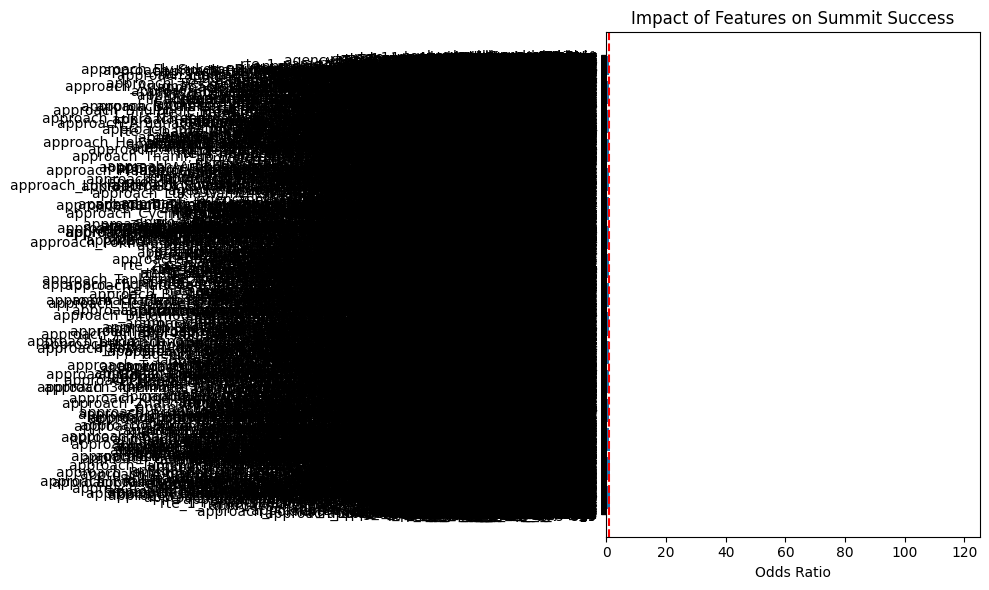

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(coeffs['Feature'], coeffs['Odds Ratio'])
plt.xlabel("Odds Ratio")
plt.title("Impact of Features on Summit Success")
plt.axvline(1, color='red', linestyle='--')
plt.tight_layout()
plt.show()


[0.81666341 0.9655145  0.83603865 0.95791823 0.05969157 0.88973558
 0.66639207 0.9620508  0.82730359 0.77707172]


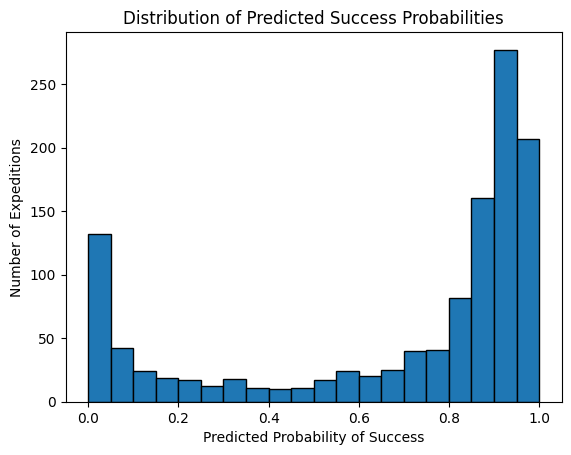

In [9]:
y_probs = model.predict_proba(X_test)[:, 1]

print(y_probs[:10])  # See first 10 probabilities

import matplotlib.pyplot as plt

plt.hist(y_probs, bins=20, edgecolor='black')
plt.xlabel("Predicted Probability of Success")
plt.ylabel("Number of Expeditions")
plt.title("Distribution of Predicted Success Probabilities")
plt.show()


In [10]:
threshold = 0.7
y_pred_custom = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.80      0.84      0.82       364
           1       0.93      0.91      0.92       825

    accuracy                           0.89      1189
   macro avg       0.86      0.87      0.87      1189
weighted avg       0.89      0.89      0.89      1189



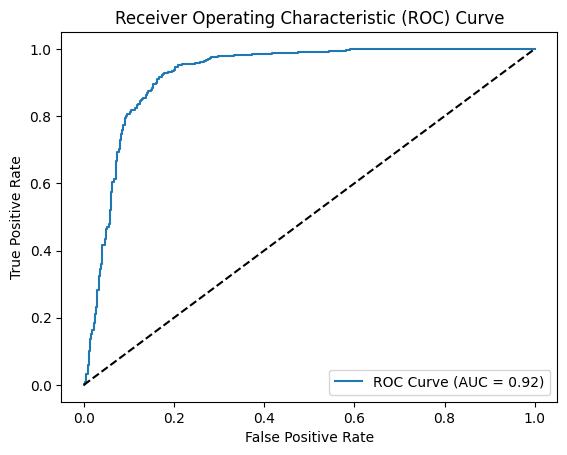

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()


In [12]:
results = X_test.copy()
results['True_Label'] = y_test
results['Predicted_Prob'] = y_probs
results['Predicted_Label'] = model.predict(X_test)
results.to_csv("logistic_regression_results.csv", index=False)


In [13]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
import sklearn

print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("matplotlib version:", matplotlib.__version__)
print("scipy version:", scipy.__version__)
print("sklearn version:", sklearn.__version__)


Python version: 3.11.7 (tags/v3.11.7:fa7a6f2, Dec  4 2023, 19:24:49) [MSC v.1937 64 bit (AMD64)]
pandas version: 2.3.0
numpy version: 1.26.4
matplotlib version: 3.8.2
scipy version: 1.11.4
sklearn version: 1.3.2
